In [75]:
%load_ext autoreload
%autoreload 2
# Always Restart Kernel after modifying backend file
from backend_aipw import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from econml.grf import RegressionForest
from sklearn.model_selection import KFold, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from scipy.special import logit, expit
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
def generate_dgp3_params(rng, n, dim_factor, spars_factor=None, fixed_s=None): # Takes as input the sample size, dimensionality factor, and sparsity factor
    # Hyperparameters controlling the strength of confounding and noise
    p_band = [0.2, 0.8]
    beta_strength = 2.5 # Before 3.0
    rho_strength = 0.8 # Before 1.2
    beta_noise = 0.5
    rho_noise = 0.3
    
    # Set Dimensionality
    n_groups = int(dim_factor * n)  # Dimensionality: grows with n
    
    # Set Sparsity
    if fixed_s is not None:
        nunique = fixed_s # Fixed Sparsity -> independent of n
    else:
        nunique = int(spars_factor * n_groups) # Relative Sparsity -> varies with n
    
    s_unique = rng.normal(0, 1, nunique) # Direct Supervisor Translation of latent factor
    s = np.resize(s_unique, n_groups) # Direct Supervisor Translation of latent factor
    #s += 0.01 * rng.normal(0, 1, size=n_groups) # Add small noise to break perfect repetition
    
    # INCORRECT APPROACH: causes SVD convergence failure [Latent sparsity]
    #s = np.zeros(n_groups)
    #active_idx = rng.choice(n_groups, size=nunique, replace=False) # Controlling which groups are assigned signal. Rest of Groups have zero signal
    #s[active_idx] = rng.normal(0, 1, size=nunique)

    # Baseline outcomes (beta_g) are driven by latent 's'
    beta_g = beta_strength * s + beta_noise * rng.normal(0, 1, size=n_groups)
    # Propensity latent score (rho_latent) is ALSO driven by 's' -> Strong Confounding!
    rho_latent = rho_strength * s + rho_noise * rng.normal(0, 1, size=n_groups)

    # Bound Propensities cleanly strictly within p_band
    a = logit(p_band[0])
    b = logit(p_band[1])
    rho_g = np.clip(rho_latent, a, b)
    p_g = expit(rho_g) # convert back to probabilities

    return n_groups, beta_g, p_g

In [77]:
# --- New Supervisor-Inspired DGP 3 ---
def dgp3_supervisor(rng, n, n_groups, beta_g, p_g):
    """
    High-dimensional, strongly confounded DGP based on supervisor's R code.
    Breaks AIPW by combining sparsity with extreme correlation between 
    outcomes and propensity scores.
    """
    # Generate the Sample
    gid = rng.integers(0, n_groups, size=n)
    
    # One-hot encoding matrix [Structural sparsity]
    X = np.zeros((n, n_groups))
    X[np.arange(n), gid] = 1.0

    # Map group parameters to individuals
    mu0 = beta_g[gid]
    mu1 = mu0 + 1.0  # Constant treatment effect tau = 1.0
    p = p_g[gid]

    # Assign treatment based on confounded propensity
    D = rng.binomial(1, p)

    # Generate Final Outcomes
    sigma_y = 1.0
    Y0 = mu0 + rng.normal(0, sigma_y, size=n)
    Y1 = mu1 + rng.normal(0, sigma_y, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [78]:
"""
Types of Machine Learers:
1) Linear Learners: OLS, Ridge, Lasso, Elastic Net, Fused Lasso
2) Tree-based Learners: Random Forest, Extra Trees, Honest Forest
3) Boosted Decision-Tree Learners: Gradient Boosting, CatBoost, XGBoost
4) Kernel-based Learners: Kernel Ridge Regression, Support Vector Regression
5) Neural Networks: 
"""

learners_regime = {
    # Worst Estimator to Best Estimator
    # 0) Variants of OLS
    "OLS_sklearn": LinearRegression(),
    #"OLS_statsmodels": StatsmodelsOLS(),
    #"OLS_numpy": NumpyOLS(),
    #"OLS_scipy": ScipyOLS(),
    # 1) Linear Learners
    "OLS_Strict": StrictNormalOLS(fit_intercept=False), # OLS without intercept (enforces zero signal for zero features)
    "OLS_Safe": SafeNormalOLS(fit_intercept=False), # OLS with safety checks (e.g., regularization, feature selection)
    "Lasso": Lasso(alpha=1.0, max_iter=10000), # Lasso with default parameters (alpha=1.0)
    "Ridge": Ridge(alpha=1.0), # Ridge with default parameters (alpha=1.0)
#    "ElasticNet": ElasticNet(max_iter=10000), # Elastic Net
    "FusedLasso": FusedLasso(alpha1=0.1, alpha2=0.1), # Fused Lasso Implementation
#    # 2) Tree-baseed Learners
#    "RF": RandomForestRegressor(n_estimators=300, random_state=123, n_jobs=1), # Random Forest
#    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, bootstrap=True, n_jobs=1),
#    "HonestForest": RegressionForest(n_estimators=300, min_samples_leaf=5),
#    # 3) Boosted Decision-Tree Learners
#    "GB": GradientBoostingRegressor(n_estimators=300, random_state=123), # Gradient Boosting
#    "CatBoost": CatBoostRegressor(verbose=0, random_state=123, iterations=300, thread_count=1), # CatBoost
#    "XGBoost": XGBRegressor(n_estimators=300, random_state=123, n_jobs=1), # XGBoost
#    # 4) Kernel-based Leaners
#    "KRR_RBF": KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1), # Kernel Ridge Regression
#    "SVR_RBF": SVR(kernel='rbf', C=1.0, epsilon=0.1), # # Support Vector Regression
#    # 5) Neural Networks
#    "NeuralNet": MLPRegressor(random_state=123, max_iter=500),
}

#"PCR": Pipeline([
#    ("scaler", StandardScaler()),
#    ("pca", PCA(svd_solver="auto")),
#    ("regressor", LinearRegression()),
#]),
# 2) Manifold Learners
#"KNN": KNeighborsRegressor(n_neighbors=10, weights='distance'),
#"KNN": Pipeline([
#    ("scaler", StandardScaler()),
#    ("knn", KNeighborsRegressor())
#]),

In [79]:
# DGP 3
n = 100 # Sample size
dim_factor = 0.8 # Dimensionality factor: when dim_factor > 1.0 the number of groups exceeds the sample size, creating a high-dimensional setting 
#spars_factor = 0.5 # Sparsity factor: when spars_factor = 1.0, there is no sparsity
constant_fixed_sparsity = 15

simulations = 200

print("DGP 3")
print("Sample Size", n)
print("Dimensionality", dim_factor)
print("Constant Fixed Sparsity", constant_fixed_sparsity)

n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=dim_factor, spars_factor=None, fixed_s = constant_fixed_sparsity)
tuned_learners_3 = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
print("Log: Hyperparameters Tuned")
print(monte_carlo_parallel(dgp3_supervisor, tuned_learners_3, n=n, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g))

DGP 3
Sample Size 100
Dimensionality 0.8
Constant Fixed Sparsity 15
Log: Hyperparameters Tuned
                 Mean      Bias  Variance  Mean_SD_Err      RMSE  CI_Width  \
Learner                                                                      
OLS_sklearn  1.677385  0.677385  0.179264     0.415082  0.798260  1.627123   
OLS_Strict   1.770545  0.770545  0.179953     0.397788  0.879087  1.559328   
OLS_Safe     1.770545  0.770545  0.179953     0.397788  0.879087  1.559328   
Lasso        1.706394  0.706394  0.177907     0.418158  0.822198  1.639179   
Ridge        1.741536  0.741536  0.177630     0.423588  0.852419  1.660465   
FusedLasso   1.775604  0.775604  0.179748     0.440542  0.883409  1.726926   

             Coverage  
Learner                
OLS_sklearn     0.600  
OLS_Strict      0.490  
OLS_Safe        0.490  
Lasso           0.565  
Ridge           0.550  
FusedLasso      0.545  


Running simulation for dim_factor=0.1...


{'Coverage': <Figure size 1000x600 with 1 Axes>,
 'RMSE': <Figure size 1000x600 with 1 Axes>,
 'CI_Width': <Figure size 1000x600 with 1 Axes>,
 'Mean': <Figure size 1000x600 with 1 Axes>,
 'Bias': <Figure size 1000x600 with 1 Axes>,
 'Variance': <Figure size 1000x600 with 1 Axes>}

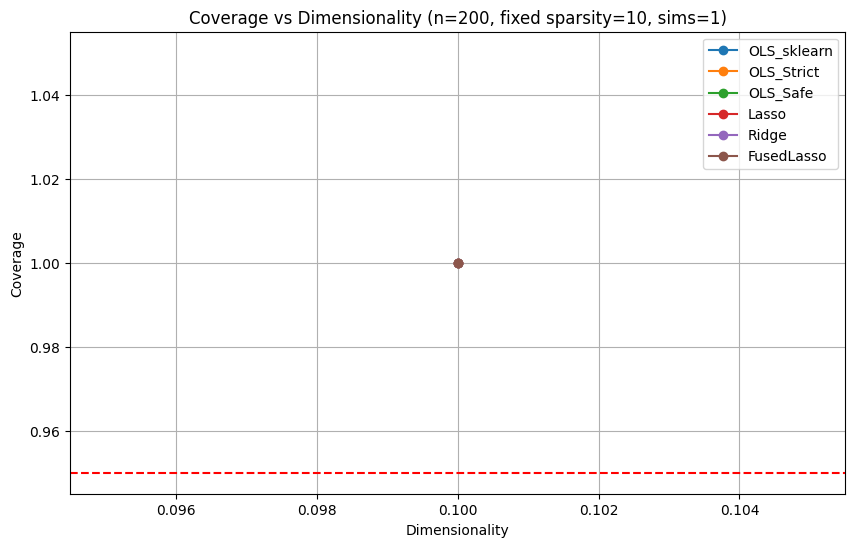

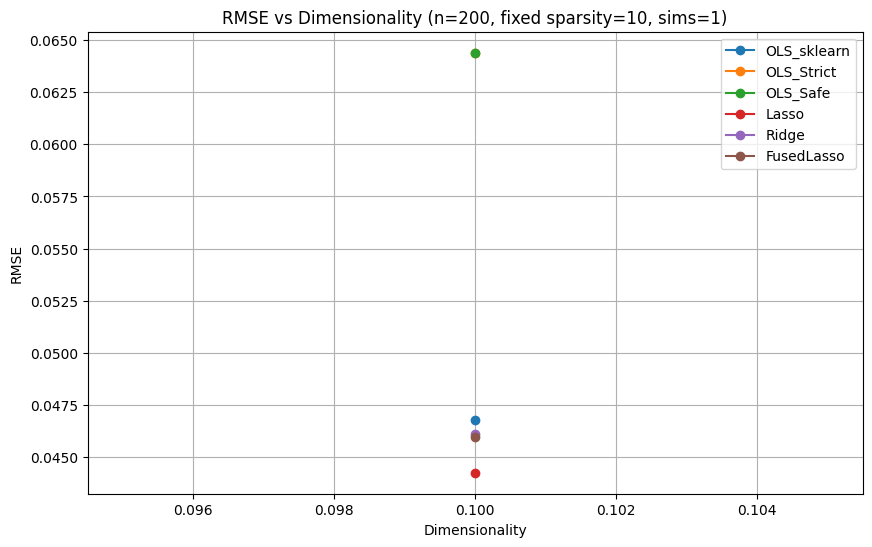

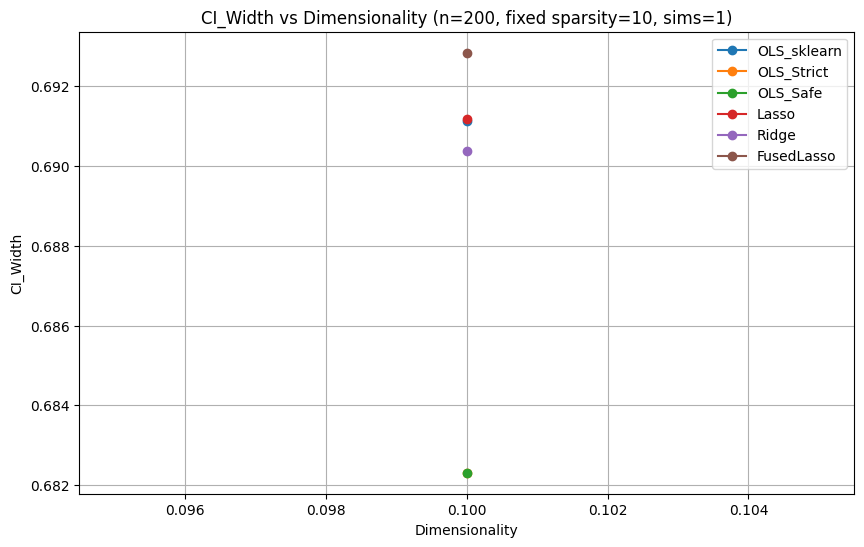

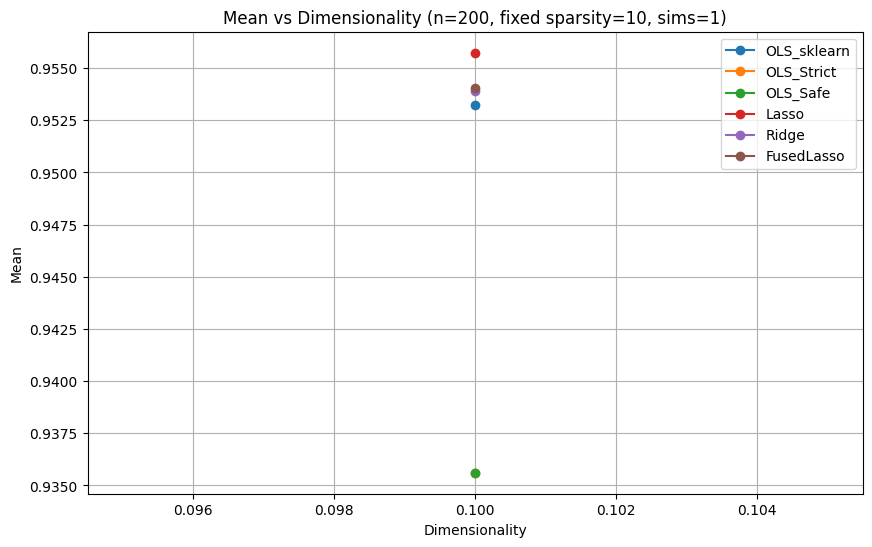

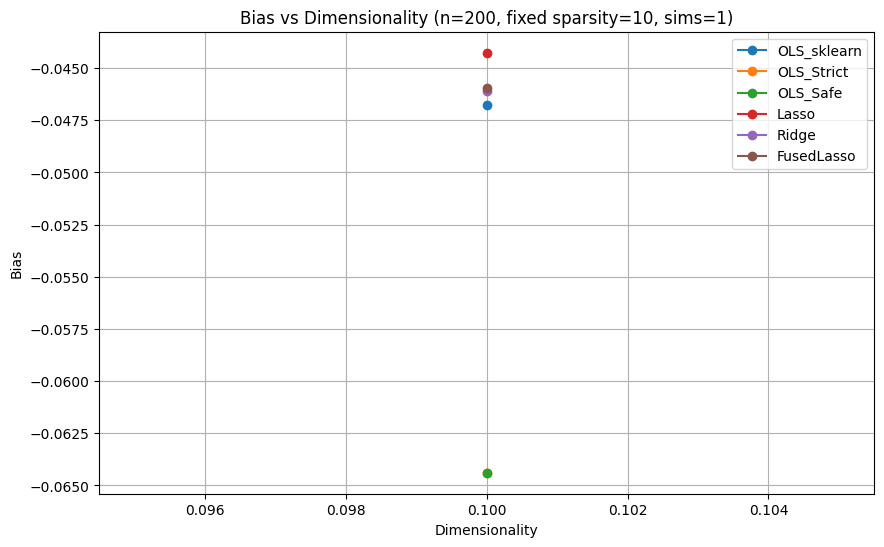

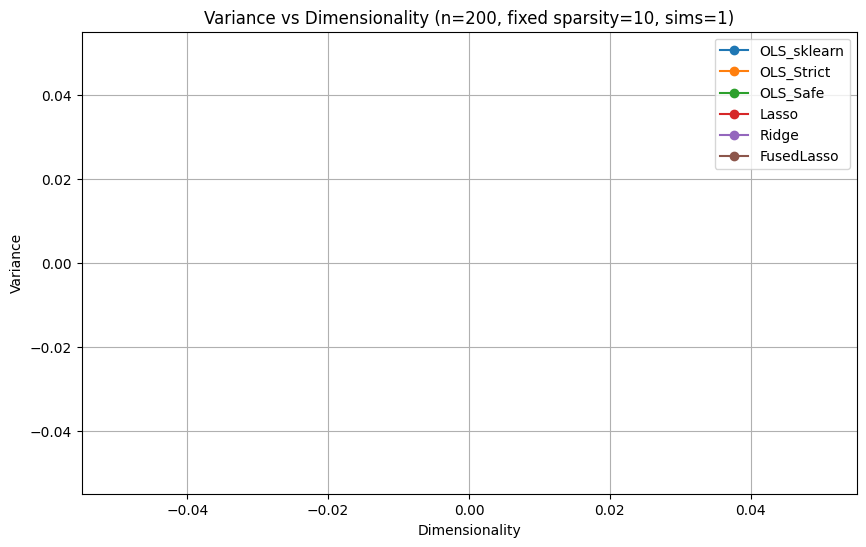

In [80]:
# ANALYSIS - Dimensionality (1) [Constant sample size, Constant fixed sparsity]
varying_dimensionality_sizes = [0.1]#, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
constant_sample_size = 200
constant_fixed_sparsity = 10 # unique groups

simulations = 1
results_n = []

for dim in varying_dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=constant_sample_size, dim_factor=dim, spars_factor=None, fixed_s=constant_fixed_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=constant_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=constant_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['Dimensionality'] = dim
    results_n.append(batch_results.reset_index())
df_n = pd.concat(results_n)

plot_metrics_vs_x(
    df_n, 
    x_col="Dimensionality", 
    title_suffix=f"n={fixed_sample_size}, fixed sparsity={constant_fixed_sparsity}, sims={simulations}",
    output_dir="../../results", 
    filename_prefix="VaryingDIMfix"
)

Running simulation for dim_factor=0.1...


{'Coverage': <Figure size 1000x600 with 1 Axes>,
 'RMSE': <Figure size 1000x600 with 1 Axes>,
 'CI_Width': <Figure size 1000x600 with 1 Axes>,
 'Mean': <Figure size 1000x600 with 1 Axes>,
 'Bias': <Figure size 1000x600 with 1 Axes>,
 'Variance': <Figure size 1000x600 with 1 Axes>}

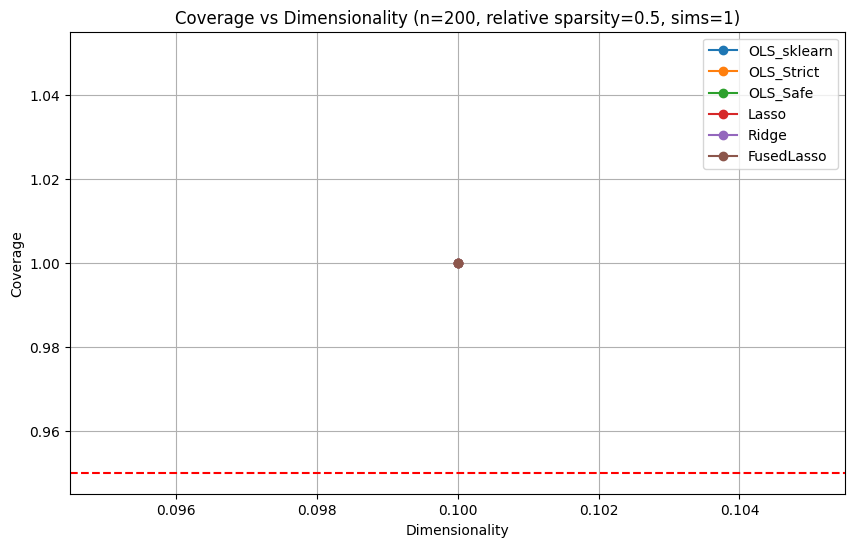

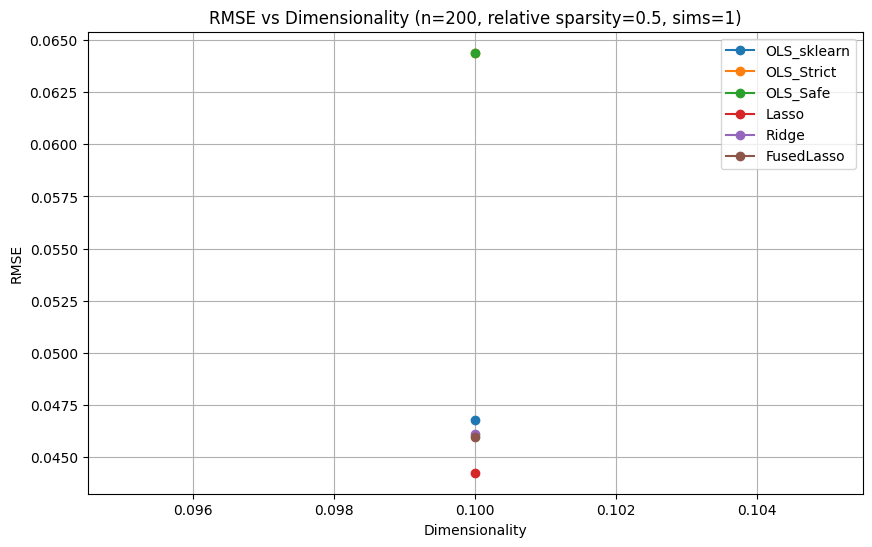

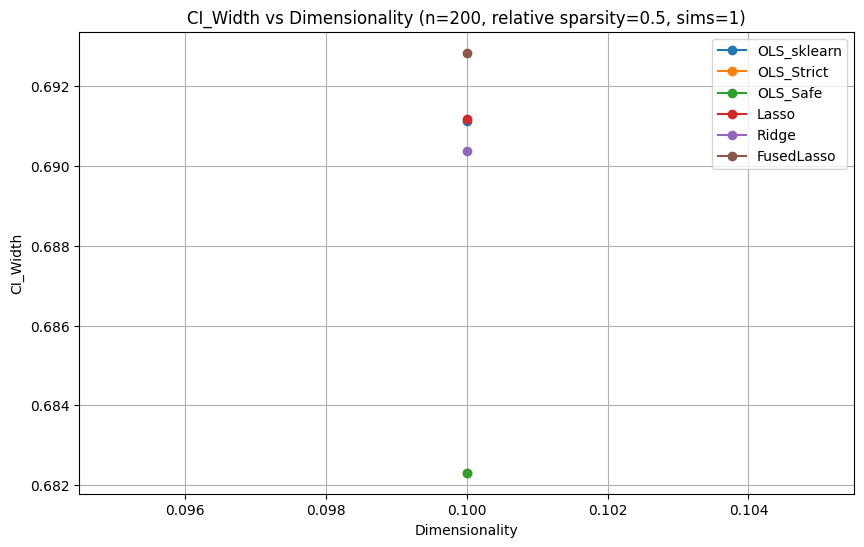

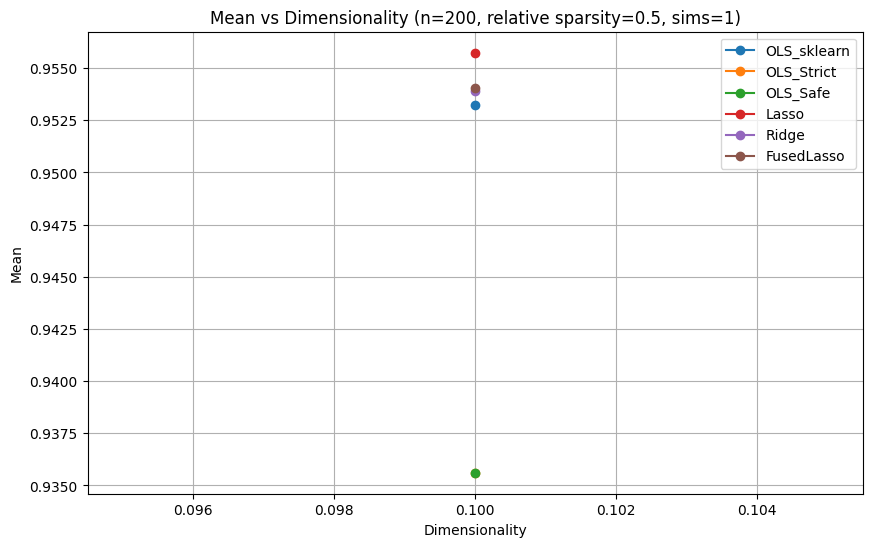

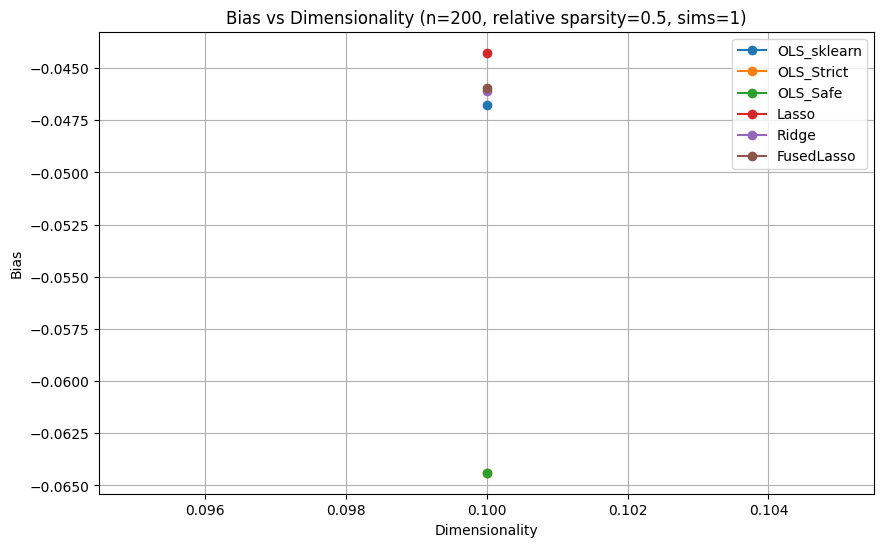

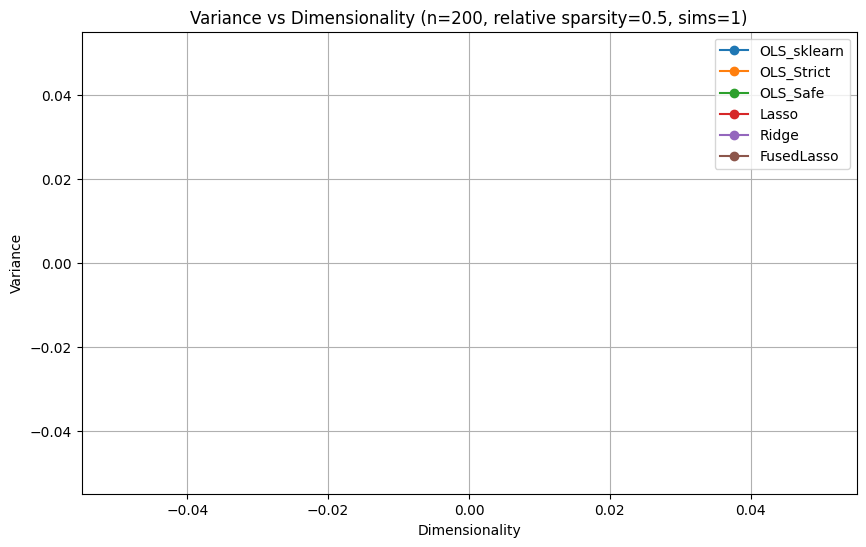

In [81]:
# ANALYSIS - Dimensionality (2) [Constant sample size, Constant relative sparsity]
varying_dimensionality_sizes = [0.1]#, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
constant_sample_size = 200
constant_relative_sparsity = 0.5

simulations = 1
results_n = []

for dim in varying_dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=constant_sample_size, dim_factor=dim, spars_factor=constant_relative_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=constant_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=constant_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['Dimensionality'] = dim
    results_n.append(batch_results.reset_index())
df_n = pd.concat(results_n)

plot_metrics_vs_x(
    df_n, 
    x_col="Dimensionality", 
    title_suffix=f"n={fixed_sample_size}, relative sparsity={constant_relative_sparsity}, sims={simulations}",
    output_dir="../../results", 
    filename_prefix="VaryingDIMrel"
)

Running simulation for spars_factor=0.2...


{'Coverage': <Figure size 1000x600 with 1 Axes>,
 'RMSE': <Figure size 1000x600 with 1 Axes>,
 'CI_Width': <Figure size 1000x600 with 1 Axes>,
 'Mean': <Figure size 1000x600 with 1 Axes>,
 'Bias': <Figure size 1000x600 with 1 Axes>,
 'Variance': <Figure size 1000x600 with 1 Axes>}

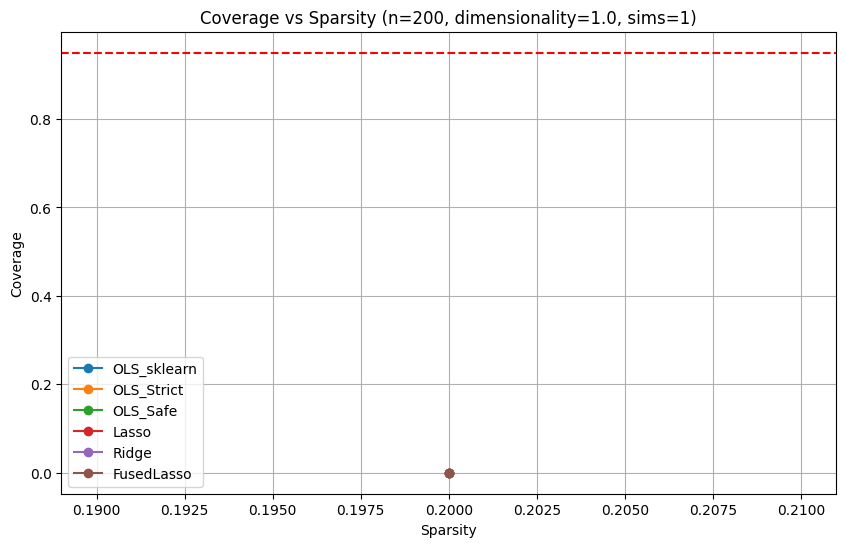

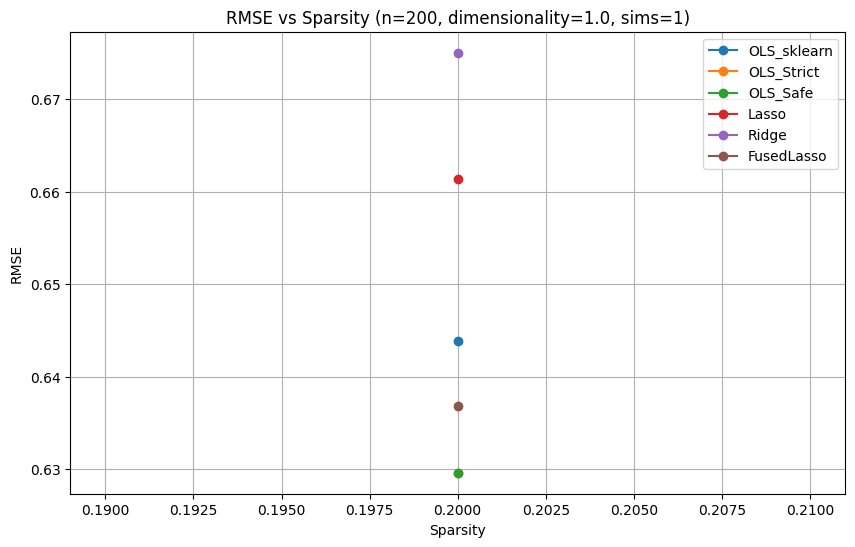

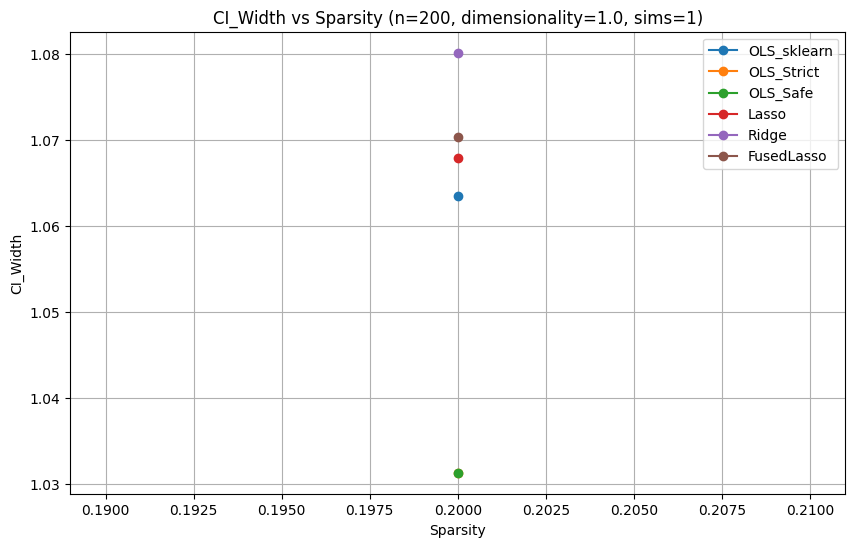

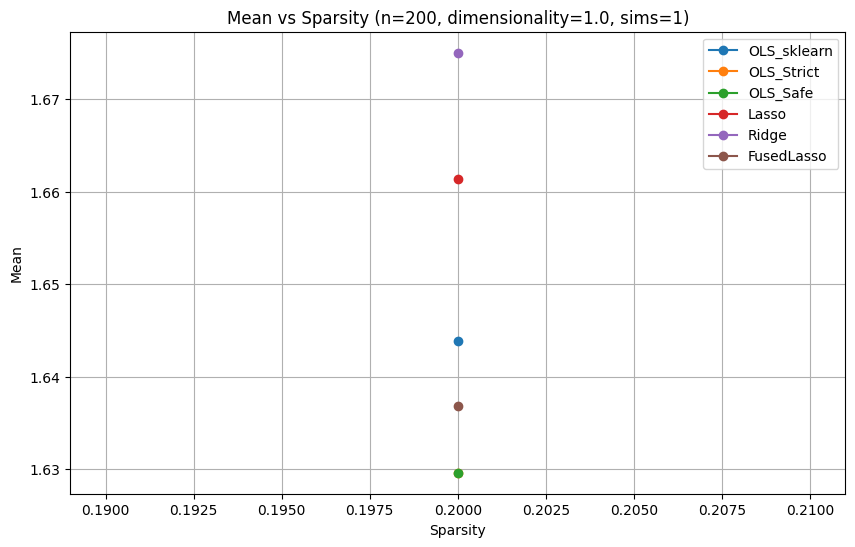

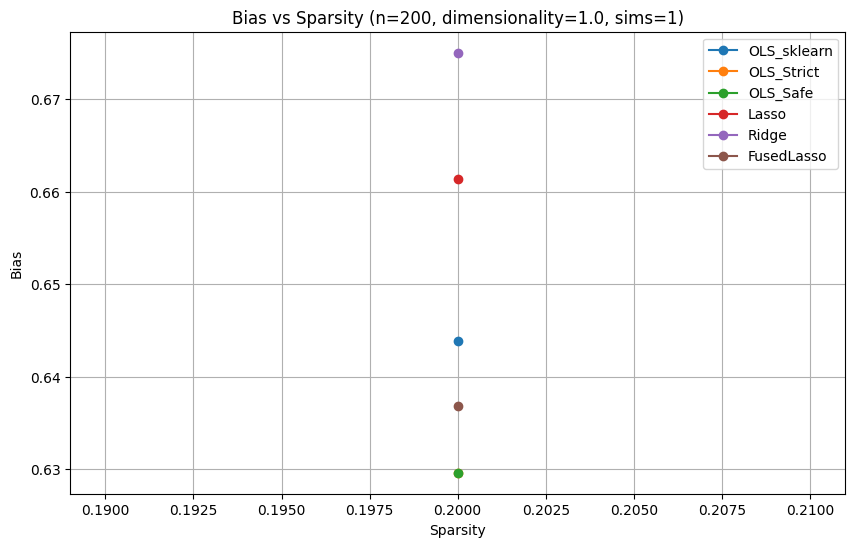

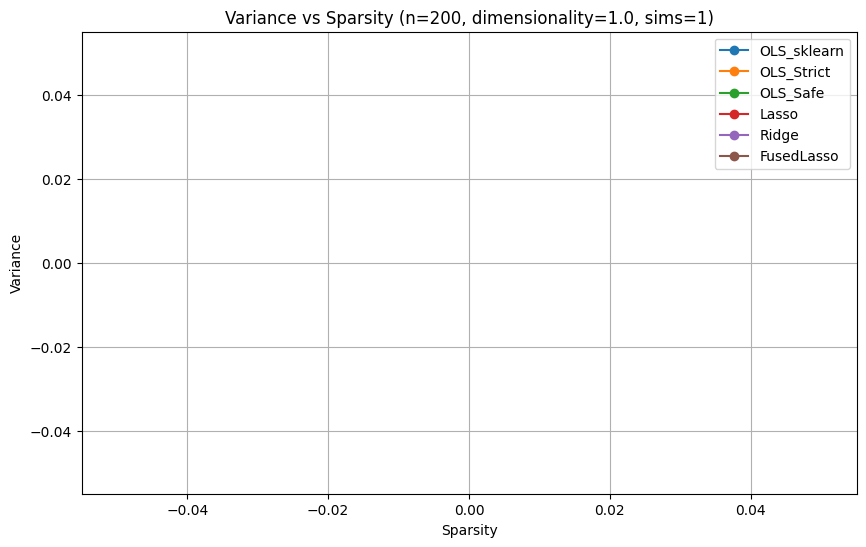

In [82]:
# ANALYSIS - Sparsity
varying_sparsity_sizes = [0.2]#, 0.4, 0.6, 0.8, 1.0] # Relative Sparsity factors to determine number of unique signals
constant_sample_size = 200
constant_dimensionality_size = 1.0 # 0.8 was too high

simulations = 1
results_n = []

for spars in varying_sparsity_sizes:
    print(f"Running simulation for spars_factor={spars}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=constant_sample_size, dim_factor=constant_dimensionality_size, spars_factor=spars) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=constant_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=constant_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['Sparsity'] = spars
    results_n.append(batch_results.reset_index())
df_n = pd.concat(results_n)

plot_metrics_vs_x(
    df_n, 
    x_col="Sparsity", 
    title_suffix=f"n={fixed_sample_size}, dimensionality={constant_dimensionality_size}, sims={simulations}",
    output_dir="../../results", 
    filename_prefix="VaryingSPARS"
)

Running simulation for sample_size=50...


{'Coverage': <Figure size 1000x600 with 1 Axes>,
 'RMSE': <Figure size 1000x600 with 1 Axes>,
 'CI_Width': <Figure size 1000x600 with 1 Axes>,
 'Mean': <Figure size 1000x600 with 1 Axes>,
 'Bias': <Figure size 1000x600 with 1 Axes>,
 'Variance': <Figure size 1000x600 with 1 Axes>}

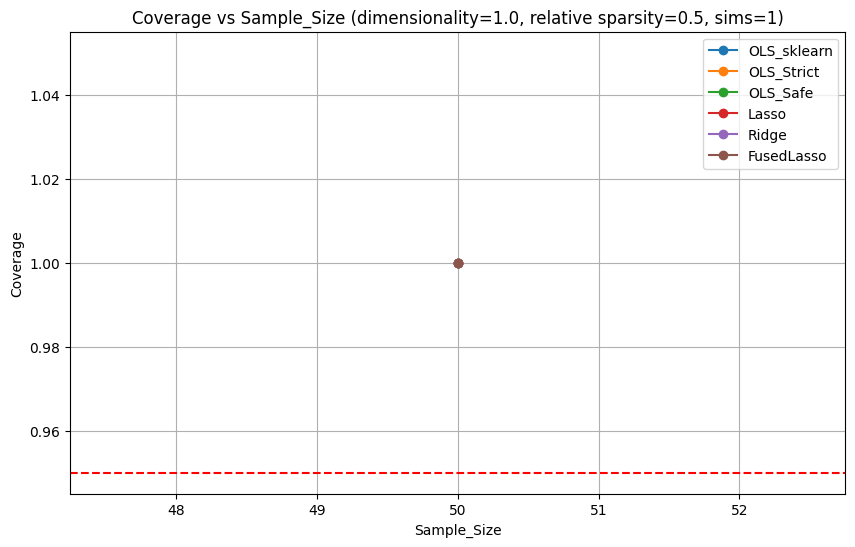

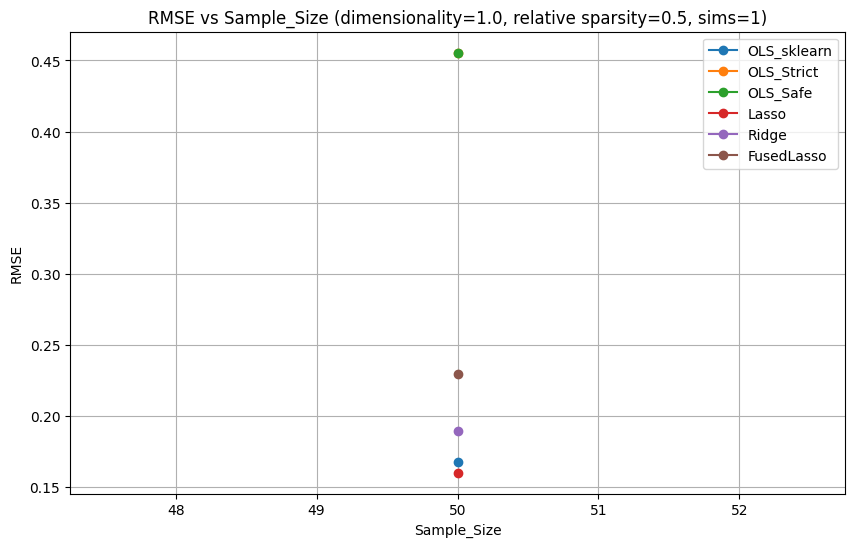

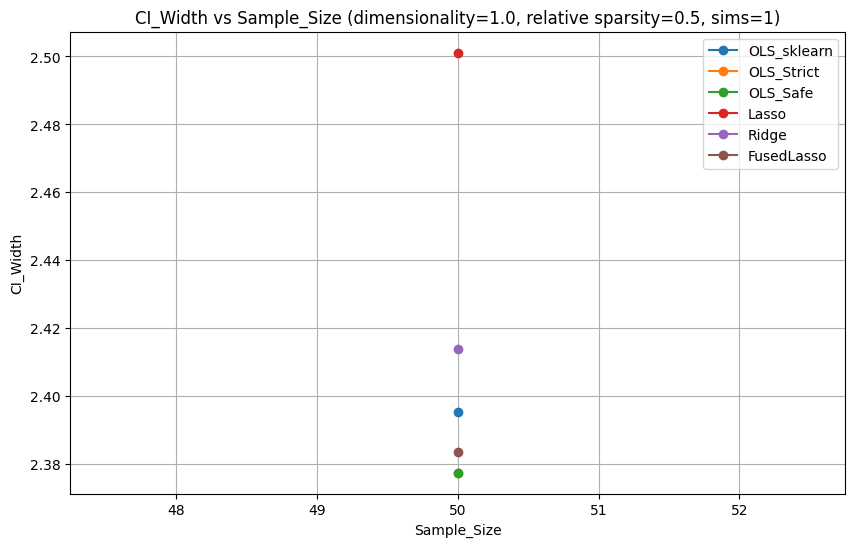

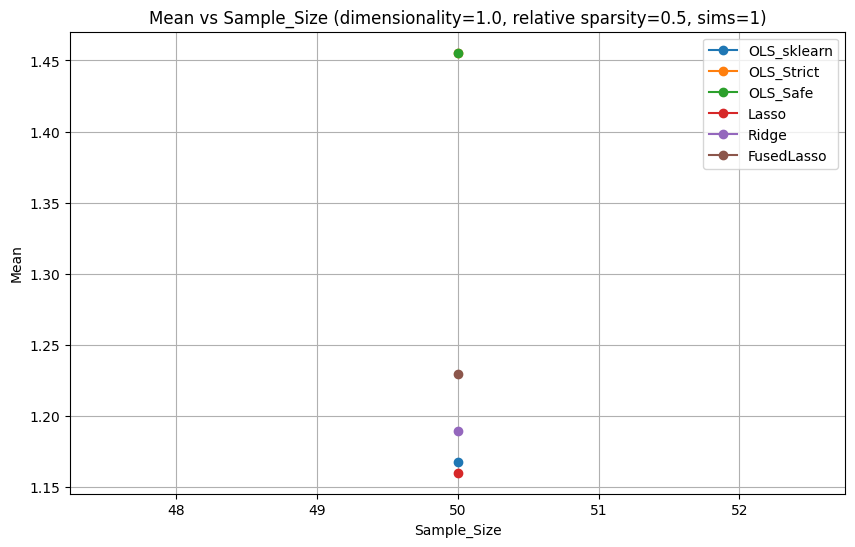

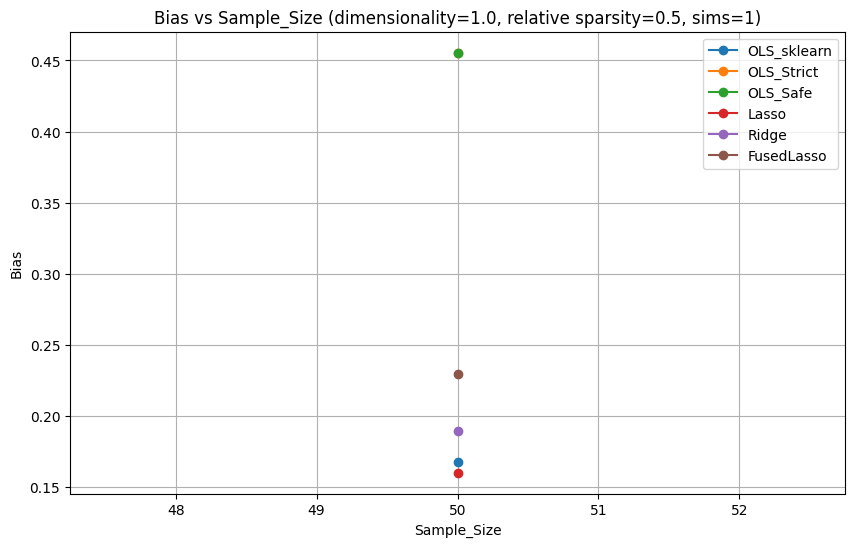

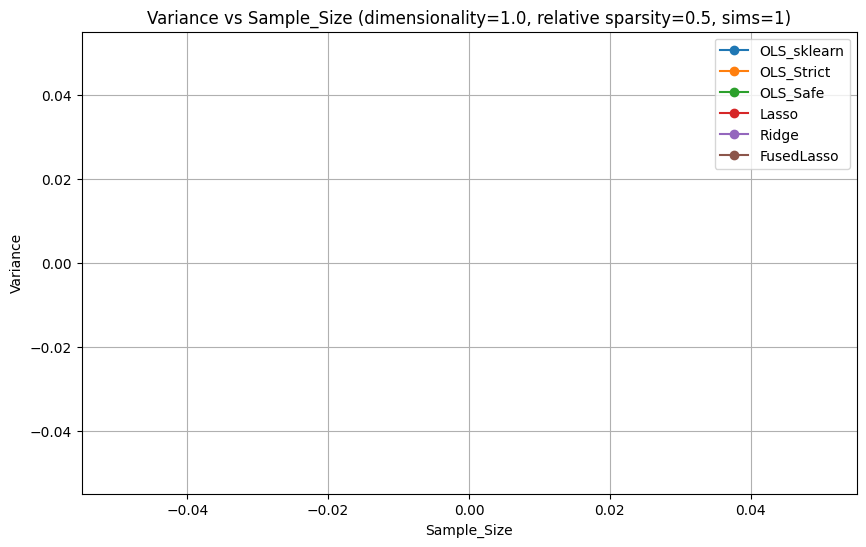

In [83]:
# ANALYSIS - Sample Size
sample_sizes = [50]#, 100, 200, 400, 800] # Sample sizes to test
fixed_dimensionality_size = 1.0 # 0.8 was too high
fixed_sparsity_size = 0.5

simulations = 1
results_n = []

for n in sample_sizes:
    print(f"Running simulation for sample_size={n}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=fixed_dimensionality_size, spars_factor=fixed_sparsity_size) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=n, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['Sample_Size'] = n
    results_n.append(batch_results.reset_index())
df_n = pd.concat(results_n)

plot_metrics_vs_x(
    df_n, 
    x_col="Sample_Size", 
    title_suffix=f"dimensionality={constant_dimensionality_size}, relative sparsity={constant_relative_sparsity}, sims={simulations}",
    output_dir="../../results", 
    filename_prefix="VaryingSAMP"
)